# 01 — Data Understanding and Exploration

Document the dataset context, structure, quality, distributions, and initial analytical findings before data preparation and modeling.

## 1. Study Context

Customer churn occurs when a customer ends their relationship with a service provider. In the telecommunications context, identifying patterns associated with churn can support more focused customer-retention actions.

This study uses the Telco Customer Churn dataset to investigate how customer characteristics, subscribed services, contract conditions, tenure, and charges relate to the `Churn` outcome. The exploratory stage will evaluate the dataset's structure and quality, identify relevant behavioral patterns, and establish evidence for the later development and comparison of binary classification models.

The dataset source summarizes the business objective as:

> “Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs.” — IBM Sample Data Sets

The study is guided by the following questions:

* Which customer, service, and account characteristics are most associated with churn?
* Are there data-quality issues or class imbalance that may affect the analysis?
* Which findings should guide data preparation, feature treatment, and model evaluation?

## 2. Dataset Source

The study uses the **Telco Customer Churn** dataset published on Kaggle by **BlastChar** and attributed to **IBM Sample Data Sets**.

| Item                     | Value                                                                                                          |
| ------------------------ | -------------------------------------------------------------------------------------------------------------- |
| Dataset                  | Telco Customer Churn                                                                                           |
| Platform                 | Kaggle                                                                                                         |
| Kaggle handle            | `blastchar/telco-customer-churn`                                                                               |
| Original attribution     | IBM Sample Data Sets                                                                                           |
| Acquisition method       | `kagglehub`, through `scripts/download_data.py`                                                                |
| Local raw-data directory | `data/raw/telco-customer-churn/`                                                                               |
| Retrieved version        | Latest available version at execution time                                                                     |
| Usage note               | Preserve the original source attribution and review the source usage conditions before redistributing the data |

The downloaded files are treated as immutable source data. Cleaning, type correction, filtering, and other transformations must not overwrite files under `data/raw/`. Derived datasets should be written to `data/interim/` or `data/processed/`.

In [1]:
# Import the utility that locates and validates the project root.
from scripts.project_context import get_project_context


# Local identifier used by this study's directories and artifacts.
DATASET_SLUG = "telco-customer-churn"

# Initialize a cross-platform project context.
PROJECT = get_project_context()

# Build the raw-data path from the dataset-specific slug.
RAW_DATA_DIR = PROJECT.path(
    "data",
    "raw",
    DATASET_SLUG,
)

# Display only safe project-relative information.
print(f"Project: {PROJECT.name}")
print(f"Raw data directory: {PROJECT.display(RAW_DATA_DIR)}")


Project: dataset-study-telco-customer-churn
Raw data directory: data/raw/telco-customer-churn


In [2]:
# Import the Kaggle acquisition operation.
from scripts.download_data import acquire_kaggle_dataset


# Public Kaggle identifier for this study's dataset.
DATASET_HANDLE = "blastchar/telco-customer-churn"

# Download the dataset or reuse its existing local materialization.
# Third-party progress output is disabled to avoid exposing absolute paths.
acquisition = acquire_kaggle_dataset(
    handle=DATASET_HANDLE,
    destination=RAW_DATA_DIR,
    project_root=PROJECT.root,
    show_progress=False,
)

print(
    "Dataset source: "
    f"Kaggle — {acquisition.source_reference}"
)
print(
    "Raw data directory: "
    f"{PROJECT.display(acquisition.destination)}"
)
print(f"Dataset files: {len(acquisition.files)}")

for file_path in acquisition.files:
    print(f"- {file_path.name}")

Dataset source: Kaggle — blastchar/telco-customer-churn
Raw data directory: data/raw/telco-customer-churn
Dataset files: 1
- WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
import pandas as pd


# Main source file selected for this study.
DATASET_FILE_SELECTOR = (
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# Keep parsing choices visible because they affect interpretation.
CSV_READ_OPTIONS = {}

DATASET_FILE = acquisition.require_one_file(
    DATASET_FILE_SELECTOR
)
df = pd.read_csv(
    DATASET_FILE,
    **CSV_READ_OPTIONS,
)

print(f"Dataset file: {DATASET_FILE.name}")
print(f"Loaded shape: {df.shape}")


Dataset file: WA_Fn-UseC_-Telco-Customer-Churn.csv
Loaded shape: (7043, 21)


## 3. Unit of Observation

Each row represents one customer account identified by `customerID`.

The dataset records customer profile, subscribed services, contract and billing information, tenure, charges, and the `Churn` outcome at a specific observation point.

The uniqueness and completeness of `customerID` must be validated to confirm that each row represents one distinct customer account.

In [4]:
from scripts.validate_data import analyze_observation_unit


# Dataset-specific definition of the analytical observation.
OBSERVATION_ID = "customerID"
OBSERVATION_LABEL = "customer account"

# Produce a reusable completeness and uniqueness report.
observation_report = analyze_observation_unit(
    dataframe=df,
    identifier=OBSERVATION_ID,
)

print(f"Unit of observation: {OBSERVATION_LABEL}")
print(f"Observation identifier: {OBSERVATION_ID}")

observation_report.summary_frame()


Unit of observation: customer account
Observation identifier: customerID


,Metric,Value
0,Rows,7043
1,Non-null identifiers,7043
2,Unique identifiers,7043
3,Missing identifiers,0
4,Duplicate identifiers,0
5,Rows involved in duplication,0


In [5]:
# Confirm the expectations declared for this observation unit.
observation_report.raise_if_invalid(
    require_complete=True,
    require_unique=True,
)

print(
    "Validation passed: each row represents one distinct "
    f"{OBSERVATION_LABEL}."
)

if observation_report.has_duplicates:
    display(observation_report.duplicated_rows)
else:
    print("No duplicated observation identifiers were found.")


Validation passed: each row represents one distinct customer account.
No duplicated observation identifiers were found.


## 4. Dataset Structure

Summarize the number of rows and columns, the available fields, and the overall organization of the data.

In [6]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 7,043
Columns: 21


## 5. Feature and Target Identification

Identify the input features, the target variable, identifier fields, and columns that require special treatment.

In [7]:
# Column used as the prediction target.
TARGET_COLUMN = "Churn"

# Columns that identify observations but must not be used as predictors.
IDENTIFIER_COLUMNS = [
    "customerID",
]

In [8]:
# Validate whether all declared columns exist in the dataset.
declared_columns = {
    TARGET_COLUMN,
    *IDENTIFIER_COLUMNS,
}

missing_declared_columns = sorted(
    declared_columns.difference(df.columns)
)

if missing_declared_columns:
    raise KeyError(
        "Declared analytical columns were not found in the dataset: "
        f"{missing_declared_columns}"
    )

print("Declared analytical columns validated.")

Declared analytical columns validated.


In [9]:
# Candidate predictors exclude identifiers and the target variable.
EXCLUDED_FROM_FEATURES = {
    TARGET_COLUMN,
    *IDENTIFIER_COLUMNS,
}

FEATURE_COLUMNS = [
    column
    for column in df.columns
    if column not in EXCLUDED_FROM_FEATURES
]

print(f"Target column: {TARGET_COLUMN}")
print(f"Identifier columns: {len(IDENTIFIER_COLUMNS)}")
print(f"Candidate features: {len(FEATURE_COLUMNS)}")

Target column: Churn
Identifier columns: 1
Candidate features: 19


In [10]:
import pandas as pd


def identify_column_role(column: str) -> str:
    """Return the analytical role assigned to a dataset column."""
    if column == TARGET_COLUMN:
        return "Target"

    if column in IDENTIFIER_COLUMNS:
        return "Identifier"

    return "Candidate feature"


column_roles = pd.DataFrame(
    {
        "Column": df.columns,
        "Role": [
            identify_column_role(column)
            for column in df.columns
        ],
        "Current dtype": [
            str(df[column].dtype)
            for column in df.columns
        ],
    }
)

column_roles

,Column,Role,Current dtype
0,customerID,Identifier,str
1,gender,Candidate feature,str
2,SeniorCitizen,Candidate feature,int64
3,Partner,Candidate feature,str
4,Dependents,Candidate feature,str
5,tenure,Candidate feature,int64
6,PhoneService,Candidate feature,str
7,MultipleLines,Candidate feature,str
8,InternetService,Candidate feature,str
9,OnlineSecurity,Candidate feature,str


## 6. Data Types

Review the expected and observed data types, highlighting columns that may have been loaded with an incorrect type.

In [11]:
# Import the generic, non-mutating data-type validation operation.
from IPython.display import display

from scripts.validate_data import analyze_data_types


# Declare the expected semantic type of each raw dataset column.
EXPECTED_DATA_TYPES = {
    "customerID": "string",
    "gender": "string",
    "SeniorCitizen": "integer",
    "Partner": "string",
    "Dependents": "string",
    "tenure": "integer",
    "PhoneService": "string",
    "MultipleLines": "string",
    "InternetService": "string",
    "OnlineSecurity": "string",
    "OnlineBackup": "string",
    "DeviceProtection": "string",
    "TechSupport": "string",
    "StreamingTV": "string",
    "StreamingMovies": "string",
    "Contract": "string",
    "PaperlessBilling": "string",
    "PaymentMethod": "string",
    "MonthlyCharges": "numeric",
    "TotalCharges": "numeric",
    "Churn": "string",
}

# Compare the expected types with the dtypes observed by pandas.
# The original DataFrame is not modified.
data_type_report = analyze_data_types(
    dataframe=df,
    expected_types=EXPECTED_DATA_TYPES,
)

# Confirm that every dataset column has a declaration and that every
# declared column exists. Type mismatches are documented but do not stop
# this exploratory notebook.
data_type_report.raise_if_invalid(
    require_all_columns_declared=True,
    require_expected_columns_present=True,
    require_matching_types=False,
)

print("Data type validation summary:")
display(data_type_report.summary_frame())

print("Per-column data type assessment:")
display(data_type_report.column_frame())

if data_type_report.has_mismatches:
    print(
        "Columns requiring data-type review before modeling:"
    )
    display(data_type_report.issues_frame())
else:
    print("All observed data types match their declarations.")

Data type validation summary:


,Status,Column count
0,Match,20
1,Mismatch,1
2,Not declared,0
3,Missing column,0


Per-column data type assessment:


,Column,Expected type,Observed dtype,Observed type,Status
0,customerID,string,str,string,Match
1,gender,string,str,string,Match
2,SeniorCitizen,integer,int64,integer,Match
3,Partner,string,str,string,Match
4,Dependents,string,str,string,Match
5,tenure,integer,int64,integer,Match
6,PhoneService,string,str,string,Match
7,MultipleLines,string,str,string,Match
8,InternetService,string,str,string,Match
9,OnlineSecurity,string,str,string,Match


Columns requiring data-type review before modeling:


,Column,Expected type,Observed dtype,Observed type,Status
0,TotalCharges,numeric,str,string,Mismatch


In [12]:
SPECIAL_TREATMENT = {
    "TotalCharges": {
        "treatment": (
            "Convert to a numeric type after validating blank values."
        ),
        "reason": (
            "The column represents accumulated charges but was loaded "
            "as text."
        ),
        "status": "Recommended",
        "next_stage": "Data preparation",
    },
}

## 7. Data Dictionary

Document each column's meaning, expected values, unit, and analytical role without modifying the raw dataset.

In [13]:
# Import the generic, non-mutating data dictionary validation operation.
from IPython.display import display

from scripts.validate_data import analyze_data_dictionary


# Dataset-specific semantic documentation for the raw Telco columns.
DATA_DICTIONARY = {
    "customerID": {
        "description": "Unique identifier of the customer account.",
        "expected_values": "Unique non-empty identifier.",
        "unit": None,
    },
    "gender": {
        "description": "Customer gender recorded by the source dataset.",
        "expected_values": ("Female", "Male"),
        "unit": None,
    },
    "SeniorCitizen": {
        "description": "Indicates whether the customer is a senior citizen.",
        "expected_values": (0, 1),
        "unit": None,
    },
    "Partner": {
        "description": "Indicates whether the customer has a partner.",
        "expected_values": ("No", "Yes"),
        "unit": None,
    },
    "Dependents": {
        "description": "Indicates whether the customer has dependents.",
        "expected_values": ("No", "Yes"),
        "unit": None,
    },
    "tenure": {
        "description": "Length of the customer relationship.",
        "expected_values": "Non-negative whole number.",
        "unit": "months",
    },
    "PhoneService": {
        "description": "Indicates whether phone service is active.",
        "expected_values": ("No", "Yes"),
        "unit": None,
    },
    "MultipleLines": {
        "description": "Indicates whether multiple phone lines are active.",
        "expected_values": (
            "No",
            "Yes",
            "No phone service",
        ),
        "unit": None,
    },
    "InternetService": {
        "description": "Type of internet service subscribed by the customer.",
        "expected_values": (
            "DSL",
            "Fiber optic",
            "No",
        ),
        "unit": None,
    },
    "OnlineSecurity": {
        "description": "Status of the online security service.",
        "expected_values": (
            "No",
            "Yes",
            "No internet service",
        ),
        "unit": None,
    },
    "OnlineBackup": {
        "description": "Status of the online backup service.",
        "expected_values": (
            "No",
            "Yes",
            "No internet service",
        ),
        "unit": None,
    },
    "DeviceProtection": {
        "description": "Status of the device protection service.",
        "expected_values": (
            "No",
            "Yes",
            "No internet service",
        ),
        "unit": None,
    },
    "TechSupport": {
        "description": "Status of the technical support service.",
        "expected_values": (
            "No",
            "Yes",
            "No internet service",
        ),
        "unit": None,
    },
    "StreamingTV": {
        "description": "Status of the streaming television service.",
        "expected_values": (
            "No",
            "Yes",
            "No internet service",
        ),
        "unit": None,
    },
    "StreamingMovies": {
        "description": "Status of the streaming movies service.",
        "expected_values": (
            "No",
            "Yes",
            "No internet service",
        ),
        "unit": None,
    },
    "Contract": {
        "description": "Current customer contract term.",
        "expected_values": (
            "Month-to-month",
            "One year",
            "Two year",
        ),
        "unit": None,
    },
    "PaperlessBilling": {
        "description": "Indicates whether paperless billing is enabled.",
        "expected_values": ("No", "Yes"),
        "unit": None,
    },
    "PaymentMethod": {
        "description": "Method used by the customer to pay charges.",
        "expected_values": (
            "Electronic check",
            "Mailed check",
            "Bank transfer (automatic)",
            "Credit card (automatic)",
        ),
        "unit": None,
    },
    "MonthlyCharges": {
        "description": "Amount charged to the customer each month.",
        "expected_values": "Non-negative numeric value.",
        "unit": "currency units per month",
    },
    "TotalCharges": {
        "description": "Accumulated charges during the customer relationship.",
        "expected_values": (
            "Non-negative numeric value or blank raw value."
        ),
        "unit": "currency units",
    },
    "Churn": {
        "description": "Indicates whether the customer left the company.",
        "expected_values": ("No", "Yes"),
        "unit": None,
    },
}

# Validate documentation coverage and derive analytical roles from the
# target and identifier declarations created in the previous section.
data_dictionary_report = analyze_data_dictionary(
    dataframe=df,
    dictionary=DATA_DICTIONARY,
    target=TARGET_COLUMN,
    identifiers=IDENTIFIER_COLUMNS,
)

data_dictionary_report.raise_if_invalid(
    require_all_columns_documented=True,
    require_documented_columns_present=True,
)

print("Data dictionary validation summary:")
display(data_dictionary_report.summary_frame())

print("Per-column data dictionary:")
display(data_dictionary_report.column_frame())

if not data_dictionary_report.is_complete:
    print("Data dictionary coverage issues:")
    display(data_dictionary_report.issues_frame())

Data dictionary validation summary:


,Status,Column count
0,Documented,21
1,Not documented,0
2,Missing column,0


Per-column data dictionary:


,Column,Description,Expected values,Unit,Analytical role,Status
0,customerID,Unique identifier of the customer account.,Unique non-empty identifier.,,Identifier,Documented
1,gender,Customer gender recorded by the source dataset.,"Female, Male",,Candidate feature,Documented
2,SeniorCitizen,Indicates whether the customer is a senior cit...,"0, 1",,Candidate feature,Documented
3,Partner,Indicates whether the customer has a partner.,"No, Yes",,Candidate feature,Documented
4,Dependents,Indicates whether the customer has dependents.,"No, Yes",,Candidate feature,Documented
5,tenure,Length of the customer relationship.,Non-negative whole number.,months,Candidate feature,Documented
6,PhoneService,Indicates whether phone service is active.,"No, Yes",,Candidate feature,Documented
7,MultipleLines,Indicates whether multiple phone lines are act...,"No, Yes, No phone service",,Candidate feature,Documented
8,InternetService,Type of internet service subscribed by the cus...,"DSL, Fiber optic, No",,Candidate feature,Documented
9,OnlineSecurity,Status of the online security service.,"No, Yes, No internet service",,Candidate feature,Documented


## 8. Missing and Invalid Values

Investigate absent, blank, inconsistent, or invalid values and describe their potential impact on the analysis.

In [14]:
# Import the generic, non-mutating value-quality validation operation.
from IPython.display import display

from scripts.validate_values import analyze_missing_and_invalid_values


def required_category(*allowed_values: object) -> dict[str, object]:
    """Build a rule for a required categorical Telco column."""
    return {
        "required": True,
        "allow_blank": False,
        "allowed_values": allowed_values,
        "strip_strings": True,
        "case_sensitive": False,
    }


# Dataset-specific operational rules for missing and invalid values.
VALUE_VALIDATION_RULES = {
    "customerID": {
        "required": True,
        "allow_blank": False,
    },
    "gender": required_category("Female", "Male"),
    "SeniorCitizen": {
        "required": True,
        "allow_blank": False,
        "allowed_values": (0, 1),
    },
    "Partner": required_category("No", "Yes"),
    "Dependents": required_category("No", "Yes"),
    "tenure": {
        "required": True,
        "allow_blank": False,
        "integer": True,
        "minimum": 0,
    },
    "PhoneService": required_category("No", "Yes"),
    "MultipleLines": required_category(
        "No",
        "Yes",
        "No phone service",
    ),
    "InternetService": required_category(
        "DSL",
        "Fiber optic",
        "No",
    ),
    "OnlineSecurity": required_category(
        "No",
        "Yes",
        "No internet service",
    ),
    "OnlineBackup": required_category(
        "No",
        "Yes",
        "No internet service",
    ),
    "DeviceProtection": required_category(
        "No",
        "Yes",
        "No internet service",
    ),
    "TechSupport": required_category(
        "No",
        "Yes",
        "No internet service",
    ),
    "StreamingTV": required_category(
        "No",
        "Yes",
        "No internet service",
    ),
    "StreamingMovies": required_category(
        "No",
        "Yes",
        "No internet service",
    ),
    "Contract": required_category(
        "Month-to-month",
        "One year",
        "Two year",
    ),
    "PaperlessBilling": required_category("No", "Yes"),
    "PaymentMethod": required_category(
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)",
    ),
    "MonthlyCharges": {
        "required": True,
        "allow_blank": False,
        "numeric": True,
        "minimum": 0,
    },
    "TotalCharges": {
        "required": True,
        "allow_blank": False,
        "numeric": True,
        "minimum": 0,
    },
    "Churn": required_category("No", "Yes"),
}

# Investigate the raw values without replacing, dropping, or converting them.
value_quality_report = analyze_missing_and_invalid_values(
    dataframe=df,
    rules=VALUE_VALIDATION_RULES,
    max_issue_samples=10,
)

# Require complete rule coverage, but retain discovered quality problems as
# evidence instead of interrupting this exploratory notebook.
value_quality_report.raise_if_invalid(
    require_all_columns_assessed=True,
    require_rule_columns_present=True,
    require_no_quality_issues=False,
)

print("Missing and invalid values validation summary:")
display(value_quality_report.summary_frame())

print("Per-column value-quality assessment:")
display(value_quality_report.column_frame())

VALUE_QUALITY_IMPACTS = {
    "Missing value": (
        "May reduce the usable sample or require an explicit missing-value "
        "strategy during data preparation."
    ),
    "Blank value": (
        "Represents hidden missingness and may prevent type conversion or "
        "produce misleading completeness statistics."
    ),
    "Inconsistent text": (
        "May fragment one category into multiple encoded levels and distort "
        "frequency comparisons."
    ),
    "Unexpected value": (
        "May introduce an unsupported category and invalidate comparisons, "
        "encoding, or inference inputs."
    ),
    "Non-numeric value": (
        "Prevents reliable numeric conversion and can block quantitative "
        "analysis or model preparation."
    ),
    "Non-integer value": (
        "Violates the declared discrete meaning of the column and may "
        "indicate malformed source data."
    ),
    "Below minimum": (
        "Violates the expected lower bound and may distort descriptive "
        "statistics or learned relationships."
    ),
    "Above maximum": (
        "Violates the expected upper bound and may distort descriptive "
        "statistics or learned relationships."
    ),
}

if value_quality_report.has_issues:
    issue_details = value_quality_report.issues_frame()
    issue_details["Potential analytical impact"] = (
        issue_details["Issue"].map(VALUE_QUALITY_IMPACTS)
    )

    print("Values requiring review and their potential impact:")
    display(issue_details)
else:
    print("No missing, blank, inconsistent, or invalid values were found.")

# Add observed evidence to the existing preparation recommendation without
# changing the raw dataset.
quality_by_column = value_quality_report.column_frame().set_index("Column")
total_charges_quality = quality_by_column.loc["TotalCharges"]
total_charges_blank_count = int(total_charges_quality["Blank count"])
total_charges_invalid_count = int(total_charges_quality["Invalid count"])

if (
    "SPECIAL_TREATMENT" in globals()
    and "TotalCharges" in SPECIAL_TREATMENT
    and total_charges_invalid_count > 0
):
    SPECIAL_TREATMENT["TotalCharges"]["reason"] = (
        "The column represents accumulated charges, was loaded as text, "
        f"and contains {total_charges_blank_count} blank raw value(s) "
        "that require explicit handling before numeric conversion."
    )

    print("Updated evidence for the TotalCharges preparation treatment:")
    display(SPECIAL_TREATMENT["TotalCharges"])

Missing and invalid values validation summary:


,Status,Column count
0,Valid,20
1,Review required,1
2,Not assessed,0
3,Missing column,0


Per-column value-quality assessment:


,Column,Row count,Missing count,Blank count,Inconsistent count,Invalid count,Affected count,Affected percent,Issue types,Status
0,customerID,7043,0,0,0,0,0,0.0000,,Valid
1,gender,7043,0,0,0,0,0,0.0000,,Valid
2,SeniorCitizen,7043,0,0,0,0,0,0.0000,,Valid
3,Partner,7043,0,0,0,0,0,0.0000,,Valid
4,Dependents,7043,0,0,0,0,0,0.0000,,Valid
5,tenure,7043,0,0,0,0,0,0.0000,,Valid
6,PhoneService,7043,0,0,0,0,0,0.0000,,Valid
7,MultipleLines,7043,0,0,0,0,0,0.0000,,Valid
8,InternetService,7043,0,0,0,0,0,0.0000,,Valid
9,OnlineSecurity,7043,0,0,0,0,0,0.0000,,Valid


Values requiring review and their potential impact:


,Column,Issue,Raw value,Count,Potential analytical impact
0,TotalCharges,Blank value,' ',11,Represents hidden missingness and may prevent ...


Updated evidence for the TotalCharges preparation treatment:


{'treatment': 'Convert to a numeric type after validating blank values.',
 'reason': 'The column represents accumulated charges, was loaded as text, and contains 11 blank raw value(s) that require explicit handling before numeric conversion.',
 'status': 'Recommended',
 'next_stage': 'Data preparation'}

In [15]:
# Identify the rows containing hidden blank values in TotalCharges.
total_charges_blank_mask = (
    df["TotalCharges"]
    .astype("string")
    .str.strip()
    .eq("")
)

total_charges_blank_rows = df.loc[
    total_charges_blank_mask,
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "Churn",
    ],
]

print(
    "Rows with blank TotalCharges:",
    len(total_charges_blank_rows),
)

display(total_charges_blank_rows)

print("Tenure distribution among affected rows:")
display(
    total_charges_blank_rows["tenure"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("tenure")
    .reset_index(name="row_count")
)

Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


Tenure distribution among affected rows:


,tenure,row_count
0,0,11


In [16]:
SPECIAL_TREATMENT["TotalCharges"] = {
    "treatment": (
        "Trim blank strings, require blank values to occur only when "
        "tenure is zero, replace those structural blanks with zero, "
        "and convert the column to a numeric type."
    ),
    "reason": (
        "All 11 blank raw values occur in records with tenure equal "
        "to zero, indicating customers without accumulated service "
        "time rather than randomly missing charge information."
    ),
    "status": "Confirmed",
    "next_stage": "Data preparation",
}

## 9. Duplicate Records

Check for duplicated observations and determine whether they represent data-quality issues or valid repeated records.

In [17]:
# Import the generic, non-mutating duplicate-record analysis.
from IPython.display import display

from scripts.validate_duplicates import analyze_duplicate_records


# Analyze exact duplicates, repeated identifiers, and feature profiles
# without removing or modifying any observation.
duplicate_report = analyze_duplicate_records(
    dataframe=df,
    identifiers=IDENTIFIER_COLUMNS,
    feature_columns=FEATURE_COLUMNS,
    target=TARGET_COLUMN,
    max_group_samples=10,
)

print("Duplicate-record analysis summary:")
display(duplicate_report.summary_frame())

# Exact duplicates and repeated identifiers represent potential
# data-quality problems because each row should identify one account.
if duplicate_report.has_quality_issues:
    print("Duplicate conditions requiring data-quality review:")
    display(duplicate_report.issues_frame())
else:
    print(
        "No exact duplicate records or repeated identifiers were found."
    )

if duplicate_report.has_exact_duplicates:
    print("Sample of completely duplicated records:")
    display(duplicate_report.exact_duplicates_frame())

if duplicate_report.has_duplicate_identifiers:
    print("Sample of repeated identifier groups:")
    display(duplicate_report.identifier_duplicates_frame())

# Different customers may legitimately share all candidate feature values.
# These profiles are documented separately and are not removed.
if duplicate_report.has_repeated_profiles:
    repeated_profiles = duplicate_report.repeated_profiles_frame()

    same_target_profiles = repeated_profiles.loc[
        repeated_profiles["Classification"] == "Same target"
    ].reset_index(drop=True)

    print(
        "Sample of feature profiles shared by distinct customer accounts:"
    )
    display(repeated_profiles)

    if not same_target_profiles.empty:
        print(
            "Repeated profiles with the same target represent valid "
            "repeated observations, not duplicate customer records."
        )
        display(same_target_profiles)
else:
    print(
        "No candidate-feature profiles are shared by distinct "
        "customer accounts."
    )

# Equal feature profiles with different target outcomes are an analytical
# limitation, not an automatic data-quality error.
if duplicate_report.has_target_conflicts:
    print(
        "Repeated feature profiles with different Churn outcomes:"
    )
    display(duplicate_report.target_conflicts_frame())

    print(
        "Interpretation: the currently available features do not fully "
        "determine the target outcome for these customer profiles. These "
        "records must remain in the dataset unless another independent "
        "quality problem is identified."
    )
else:
    print(
        "No target disagreement was found among repeated feature profiles."
    )

# Add a preparation requirement only when identifier duplication is
# actually supported by the observed data.
if (
    duplicate_report.has_duplicate_identifiers
    and "SPECIAL_TREATMENT" in globals()
):
    SPECIAL_TREATMENT["customerID"] = {
        "treatment": (
            "Resolve repeated customer identifiers before model "
            "preparation and preserve only records supported by an "
            "explicit reconciliation rule."
        ),
        "reason": (
            f"{duplicate_report.duplicate_identifier_group_count} "
            "repeated identifier group(s) involving "
            f"{duplicate_report.duplicate_identifier_row_count} "
            "row(s) were found."
        ),
        "status": "Required",
        "next_stage": "Data preparation",
    }

    print("Added preparation requirement for repeated customer identifiers:")
    display(SPECIAL_TREATMENT["customerID"])

# Validate conditions that violate the declared customer-account
# observation unit. Repeated profiles and target disagreements are retained
# as analytical evidence and do not fail the validation.
duplicate_report.raise_if_invalid(
    require_no_exact_duplicates=True,
    require_unique_identifiers=True,
    require_no_conflicting_identifiers=True,
    require_no_repeated_profiles=False,
    require_no_target_conflicts=False,
)

print(
    "Duplicate-record validation passed: no invalid complete-row "
    "duplication or repeated customer identifiers were found."
)

Duplicate-record analysis summary:


,Metric,Group count,Row count,Interpretation
0,Exact duplicate records,0,0,Quality issue
1,Duplicate identifiers,0,0,Quality issue
2,Conflicting duplicate identifiers,0,0,Quality issue
3,Repeated feature profiles,33,73,Potentially valid repeated records
4,Repeated profiles with the same target,15,31,Valid repeated profile
5,Repeated profiles with target disagreement,18,42,Analytical ambiguity


No exact duplicate records or repeated identifiers were found.
Sample of feature profiles shared by distinct customer accounts:


,Profile group,Row count,Distinct identifier count,Target values,Target value count,Classification,Row positions,Row indices,Feature values
0,1,2,2,'Yes',1,Same target,"(22, 1338)","(22, 1338)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
1,2,4,4,"'No', 'Yes'",2,Target disagreement,"(100, 1932, 5506, 5908)","(100, 1932, 5506, 5908)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
2,3,2,2,"'No', 'Yes'",2,Target disagreement,"(128, 4065)","(128, 4065)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
3,4,2,2,"'No', 'Yes'",2,Target disagreement,"(295, 4721)","(295, 4721)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
4,5,2,2,'No',1,Same target,"(542, 1491)","(542, 1491)","{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
5,6,2,2,'Yes',1,Same target,"(646, 964)","(646, 964)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
6,7,3,3,'No',1,Same target,"(662, 3754, 5736)","(662, 3754, 5736)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
7,8,2,2,"'No', 'Yes'",2,Target disagreement,"(684, 4789)","(684, 4789)","{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
8,9,2,2,'No',1,Same target,"(690, 2713)","(690, 2713)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
9,10,2,2,"'Yes', 'No'",2,Target disagreement,"(710, 6449)","(710, 6449)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."


Repeated profiles with the same target represent valid repeated observations, not duplicate customer records.


,Profile group,Row count,Distinct identifier count,Target values,Target value count,Classification,Row positions,Row indices,Feature values
0,1,2,2,'Yes',1,Same target,"(22, 1338)","(22, 1338)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
1,5,2,2,'No',1,Same target,"(542, 1491)","(542, 1491)","{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
2,6,2,2,'Yes',1,Same target,"(646, 964)","(646, 964)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
3,7,3,3,'No',1,Same target,"(662, 3754, 5736)","(662, 3754, 5736)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
4,9,2,2,'No',1,Same target,"(690, 2713)","(690, 2713)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."


Repeated feature profiles with different Churn outcomes:


,Profile group,Row count,Distinct identifier count,Target values,Target value count,Classification,Row positions,Row indices,Feature values
0,2,4,4,"'No', 'Yes'",2,Target disagreement,"(100, 1932, 5506, 5908)","(100, 1932, 5506, 5908)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
1,3,2,2,"'No', 'Yes'",2,Target disagreement,"(128, 4065)","(128, 4065)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
2,4,2,2,"'No', 'Yes'",2,Target disagreement,"(295, 4721)","(295, 4721)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."
3,8,2,2,"'No', 'Yes'",2,Target disagreement,"(684, 4789)","(684, 4789)","{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
4,10,2,2,"'Yes', 'No'",2,Target disagreement,"(710, 6449)","(710, 6449)","{'gender': 'Male', 'SeniorCitizen': 0, 'Partne..."


Interpretation: the currently available features do not fully determine the target outcome for these customer profiles. These records must remain in the dataset unless another independent quality problem is identified.
Duplicate-record validation passed: no invalid complete-row duplication or repeated customer identifiers were found.


## 10. Target Distribution

Examine how the target classes or values are distributed and identify possible imbalance or unusual patterns.

Target-distribution analysis summary:


,Metric,Value,Interpretation
0,Total rows,7043,All observations
1,Non-missing target values,7043,Rows used for class proportions
2,Missing target values,0,No missing target values
3,Observed classes,2,Classes with at least one observation
4,Majority class,'No',Most frequent observed class
5,Minority class,'Yes',Least frequent observed class
6,Majority share,73.4630%,Majority-class baseline accuracy
7,Minority share,26.5370%,Smallest observed class prevalence
8,Majority-to-minority ratio,2.7683,Descriptive imbalance indicator
9,Positive class,'Yes',Outcome treated as positive


Per-class target distribution:


,Class,Count,Percentage,Expected,Role
0,No,5174,73.46%,True,Majority / Negative
1,Yes,1869,26.54%,True,Minority / Positive


Target integrity validated: no missing values, unexpected classes, or absent expected classes were found.


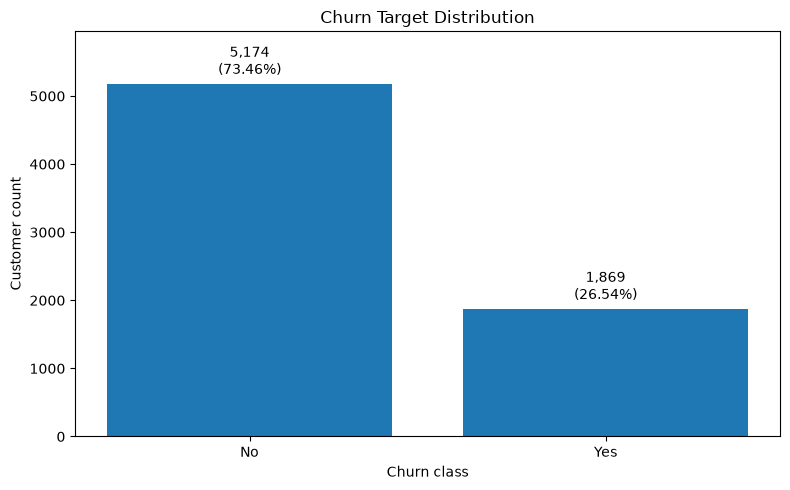

Target-distribution interpretation:
- Majority class(es): ('No',)
- Minority class(es): ('Yes',)
- Majority-class share: 73.46%
- Positive-class prevalence ('Yes'): 26.54%
- Majority-to-minority ratio: 2.7683:1
- Majority-class baseline accuracy: 73.46%
- Interpretation: The target presents a meaningful but not extreme imbalance that must be considered during splitting and evaluation.
- Analytical impact: accuracy alone may overstate performance when the majority class is substantially more frequent.
- Recommended evaluation direction: preserve class proportions through stratified splits and examine precision, recall, F1, ROC-AUC, and precision-recall metrics.
- No oversampling, undersampling, or synthetic data generation is applied in this exploratory notebook.
Registered target preparation and evaluation treatment:


{'treatment': 'Encode the binary target, preserve class proportions through stratified train-validation-test splitting, and evaluate model performance with metrics that reflect the positive and minority class. Compare class weighting during modeling before considering any resampling strategy.',
 'reason': "The positive class 'Yes' represents 26.54% of non-missing observations, while the majority class represents 73.46%. The observed majority-to-minority ratio is 2.7683:1, so accuracy alone may provide an incomplete view of predictive performance.",
 'status': 'Confirmed',
 'next_stage': 'Data preparation and model evaluation'}

In [18]:
# Import the generic, non-mutating target-distribution analysis.
from IPython.display import display
from matplotlib import pyplot as plt

from scripts.analyze_target import analyze_target_distribution


# Dataset-specific target contract.
TARGET_CLASSES = (
    "No",
    "Yes",
)

POSITIVE_TARGET_CLASS = "Yes"

# Explicit interpretation thresholds for this study.
# They describe the observed distribution but do not trigger resampling.
IMBALANCE_REVIEW_RATIO = 2.0
SEVERE_IMBALANCE_RATIO = 4.0


# Analyze the raw target without encoding or modifying the DataFrame.
target_report = analyze_target_distribution(
    dataframe=df,
    target=TARGET_COLUMN,
    expected_classes=TARGET_CLASSES,
    positive_class=POSITIVE_TARGET_CLASS,
)

print("Target-distribution analysis summary:")
display(target_report.summary_frame())

target_distribution = target_report.distribution_frame()

target_distribution_display = target_distribution.copy()
target_distribution_display["Percentage"] = (
    target_distribution_display["Percentage"]
    .map(lambda value: f"{value:.2%}")
)

print("Per-class target distribution:")
display(target_distribution_display)

if target_report.has_issues:
    print("Target conditions requiring review:")
    display(target_report.issues_frame())
else:
    print(
        "Target integrity validated: no missing values, unexpected "
        "classes, or absent expected classes were found."
    )

# Validate the declared target contract.
target_report.raise_if_invalid(
    require_no_missing_target=True,
    require_expected_classes_present=True,
    require_no_unexpected_classes=True,
)


# Visualize counts while retaining exact percentages in the labels.
figure, axis = plt.subplots(figsize=(8, 5))

bars = axis.bar(
    target_distribution["Class"].astype(str),
    target_distribution["Count"],
)

bar_labels = [
    f"{count:,}\n({percentage:.2%})"
    for count, percentage in zip(
        target_distribution["Count"],
        target_distribution["Percentage"],
        strict=True,
    )
]

axis.bar_label(
    bars,
    labels=bar_labels,
    padding=4,
)

axis.set_title("Churn Target Distribution")
axis.set_xlabel("Churn class")
axis.set_ylabel("Customer count")
axis.set_ylim(
    0,
    max(target_distribution["Count"]) * 1.15,
)

figure.tight_layout()
plt.show()


# Interpret the observed class balance using explicit study thresholds.
imbalance_ratio = target_report.imbalance_ratio

if imbalance_ratio is None:
    imbalance_interpretation = (
        "The imbalance ratio is unavailable because no valid target "
        "distribution could be calculated."
    )
elif imbalance_ratio >= SEVERE_IMBALANCE_RATIO:
    imbalance_interpretation = (
        "The target presents severe class imbalance under the explicit "
        f"study threshold of {SEVERE_IMBALANCE_RATIO:.1f}:1."
    )
elif imbalance_ratio >= IMBALANCE_REVIEW_RATIO:
    imbalance_interpretation = (
        "The target presents a meaningful but not extreme imbalance "
        "that must be considered during splitting and evaluation."
    )
elif imbalance_ratio > 1:
    imbalance_interpretation = (
        "The target presents limited class imbalance."
    )
else:
    imbalance_interpretation = (
        "The observed target classes are balanced."
    )

print("Target-distribution interpretation:")
print(f"- Majority class(es): {target_report.majority_classes}")
print(f"- Minority class(es): {target_report.minority_classes}")

if target_report.majority_share is not None:
    print(
        "- Majority-class share: "
        f"{target_report.majority_share:.2%}"
    )

if target_report.positive_class_share is not None:
    print(
        f"- Positive-class prevalence "
        f"({POSITIVE_TARGET_CLASS!r}): "
        f"{target_report.positive_class_share:.2%}"
    )

if imbalance_ratio is not None:
    print(
        "- Majority-to-minority ratio: "
        f"{imbalance_ratio:.4f}:1"
    )

if target_report.majority_baseline_accuracy is not None:
    print(
        "- Majority-class baseline accuracy: "
        f"{target_report.majority_baseline_accuracy:.2%}"
    )

print(f"- Interpretation: {imbalance_interpretation}")

print(
    "- Analytical impact: accuracy alone may overstate performance "
    "when the majority class is substantially more frequent."
)

print(
    "- Recommended evaluation direction: preserve class proportions "
    "through stratified splits and examine precision, recall, F1, "
    "ROC-AUC, and precision-recall metrics."
)

print(
    "- No oversampling, undersampling, or synthetic data generation "
    "is applied in this exploratory notebook."
)


# Register the evidence-backed target preparation and evaluation contract.
if "SPECIAL_TREATMENT" not in globals():
    SPECIAL_TREATMENT = {}

positive_share = target_report.positive_class_share
majority_share = target_report.majority_share

positive_share_text = (
    "not available"
    if positive_share is None
    else f"{positive_share:.2%}"
)

majority_share_text = (
    "not available"
    if majority_share is None
    else f"{majority_share:.2%}"
)

ratio_text = (
    "not available"
    if imbalance_ratio is None
    else f"{imbalance_ratio:.4f}:1"
)

SPECIAL_TREATMENT[TARGET_COLUMN] = {
    "treatment": (
        "Encode the binary target, preserve class proportions through "
        "stratified train-validation-test splitting, and evaluate model "
        "performance with metrics that reflect the positive and minority "
        "class. Compare class weighting during modeling before considering "
        "any resampling strategy."
    ),
    "reason": (
        f"The positive class {POSITIVE_TARGET_CLASS!r} represents "
        f"{positive_share_text} of non-missing observations, while the "
        f"majority class represents {majority_share_text}. The observed "
        f"majority-to-minority ratio is {ratio_text}, so accuracy alone "
        "may provide an incomplete view of predictive performance."
    ),
    "status": "Confirmed",
    "next_stage": "Data preparation and model evaluation",
}

print("Registered target preparation and evaluation treatment:")
display(SPECIAL_TREATMENT[TARGET_COLUMN])

## 11. Numerical Feature Exploration

Explore distributions, ranges, central tendencies, variability, outliers, and unusual values in numerical features.

## 12. Categorical Feature Exploration

Explore category frequencies, rare values, cardinality, inconsistent labels, and potentially relevant groupings.

## 13. Feature Relationships

Investigate associations between features to identify redundancy, dependencies, interactions, or unexpected relationships.

## 14. Feature-to-Target Relationships

Compare each relevant feature with the target to identify patterns, hypotheses, and variables that may support modeling.

## 15. Potential Data Leakage

Identify fields or transformations that may reveal the target directly or contain information unavailable at inference time.

## 16. Initial Data-Quality Findings

Consolidate the main structural and quality issues that must be addressed during data preparation.

## 17. Key Exploratory Insights

Summarize the most relevant patterns, contrasts, and hypotheses discovered during the exploratory analysis.

## 18. Preparation Decisions

Record the preliminary decisions that should guide cleaning, transformation, feature engineering, and dataset splitting.

## 19. Next Steps

List the actions that will be continued in the data-preparation and model-selection stages.